### IMPORTAZIONE LIBRERIE

In [434]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print ("librerie")
print("prova")

librerie
prova


#### Definizione stile grafico: sfondo bianco,griglia leggera,grafici moderni

In [435]:
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

#### Read dataset fumatori italia

In [436]:
df = pd.read_csv('fumatori_italia.csv')

### OSSERVAZIONE HEAD E TAIL
#### Abbiamo osservato la parte iniziale e finale del dataset per vedere come era composto

In [437]:
df.head()

,Anno,Sesso,Nord_ovest,Nord_est,Centro,Sud,Isole,Italia
0,1980,Maschi,52.3,48.6,53.0,61.5,56.5,54.3
1,1983,Maschi,45.3,41.0,44.5,50.6,46.1,45.6
2,1987,Maschi,42.3,34.7,39.3,43.8,43.3,40.8
3,1990,Maschi,37.6,31.7,37.5,41.7,40.9,37.8
4,1993,Maschi,34.6,29.4,34.8,38.8,38.6,35.1


In [438]:
df.tail()

,Anno,Sesso,Nord_ovest,Nord_est,Centro,Sud,Isole,Italia
47,2011,Femmine,18.0,16.2,19.2,14.3,14.1,16.6
48,2012,Femmine,17.9,16.5,17.8,13.5,16.3,16.4
49,2013,Femmine,16.1,15.6,18.6,13.2,15.5,15.8
50,2014,Femmine,15.5,14.9,15.9,12.7,14.8,14.7
51,2015,Femmine,15.4,15.4,17.3,12.6,14.4,15.0


In [439]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Anno        52 non-null     int64  
 1   Sesso       52 non-null     str    
 2   Nord_ovest  52 non-null     float64
 3   Nord_est    52 non-null     float64
 4   Centro      52 non-null     float64
 5   Sud         52 non-null     float64
 6   Isole       52 non-null     float64
 7   Italia      52 non-null     float64
dtypes: float64(6), int64(1), str(1)
memory usage: 3.4 KB


In [440]:
df.describe()

,Anno,Nord_ovest,Nord_est,Centro,Sud,Isole,Italia
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,2001.076923,24.800000,23.053846,25.826923,24.505769,24.794231,24.609615
std,9.480312,8.541571,6.759089,8.024768,12.101376,10.905070,9.128693
min,1980.000000,15.400000,14.900000,15.900000,11.900000,11.700000,14.700000
25%,1995.000000,17.875000,18.075000,19.375000,13.950000,15.175000,16.975000
50%,2001.500000,21.650000,21.400000,22.750000,21.300000,21.250000,21.250000
75%,2009.000000,30.150000,27.400000,31.675000,33.025000,32.850000,31.050000
max,2015.000000,52.300000,48.600000,53.000000,61.500000,56.500000,54.300000


### MINIMO E MASSIMO:


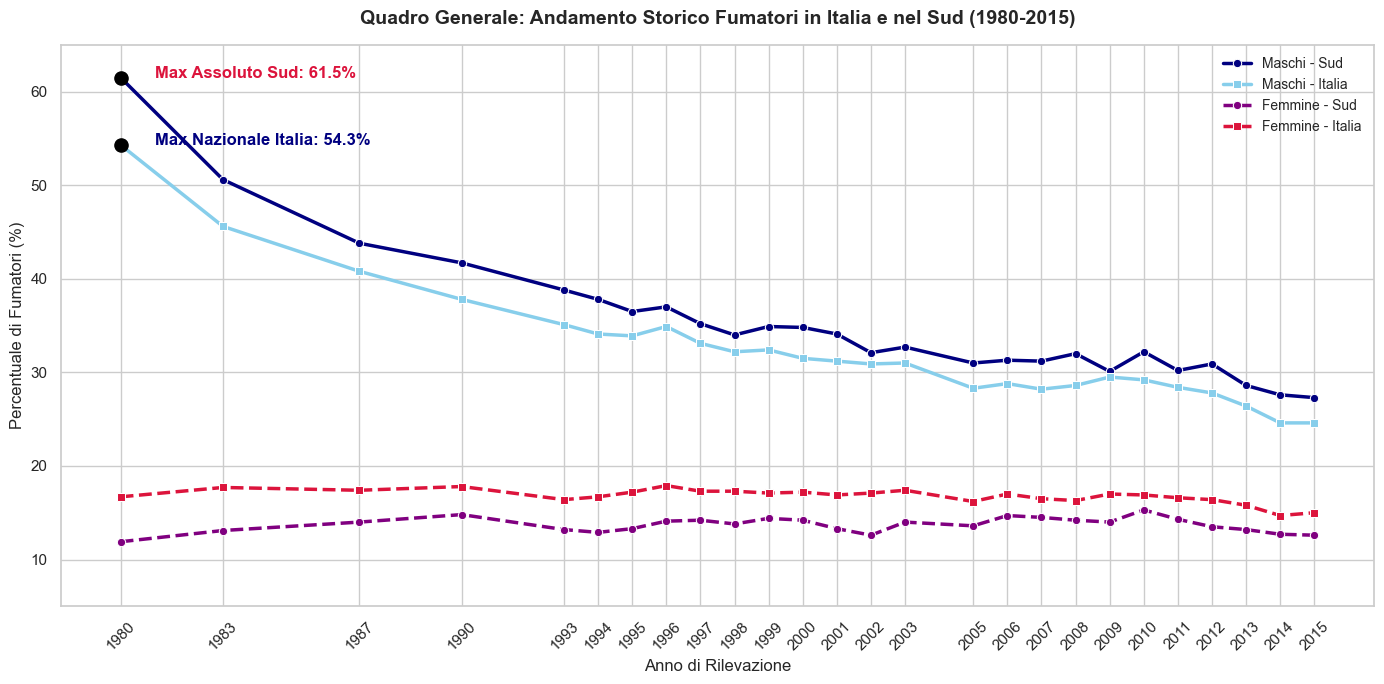

In [441]:

# Configurazione dello stile del grafico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Grafico per i Maschi (linee continue)
sns.lineplot(
    data=df[df["Sesso"] == "Maschi"],
    x="Anno",
    y="Sud",
    label="Maschi - Sud ",
    marker="o",
    linestyle="-",
    color="navy",
    linewidth=2.5,
)
sns.lineplot(
    data=df[df["Sesso"] == "Maschi"],
    x="Anno",
    y="Italia",
    label="Maschi - Italia ",
    marker="s",
    linestyle="-",
    color="skyblue",
    linewidth=2.5,
)

# 2. Grafico per le Femmine (linee tratteggiate)
sns.lineplot(
    data=df[df["Sesso"] == "Femmine"],
    x="Anno",
    y="Sud",
    label="Femmine - Sud",
    marker="o",
    linestyle="--",
    color="purple",
    linewidth=2.5,
)
sns.lineplot(
    data=df[df["Sesso"] == "Femmine"],
    x="Anno",
    y="Italia",
    label="Femmine - Italia",
    marker="s",
    linestyle="--",
    color="crimson",
    linewidth=2.5,
)

# punti di massimo assoluto del 1980 (Maschi)
plt.scatter([1980, 1980], [61.5, 54.3], color="black", s=90, zorder=5)
plt.text(
    1981,
    61.5,
    "Max Assoluto Sud: 61.5%",
    fontweight="bold",
    color="crimson",
)
plt.text(
    1981,
    54.3,
    "Max Nazionale Italia: 54.3%",
    fontweight="bold",
    color="navy",
)

# Configurazione 
plt.title(
    "Quadro Generale: Andamento Storico Fumatori in Italia e nel Sud (1980-2015)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Anno di Rilevazione", fontsize=12)
plt.ylabel("Percentuale di Fumatori (%)", fontsize=12)

plt.xticks(df["Anno"].unique(), rotation=45)
plt.ylim(5, 65)
plt.legend(loc="upper right", bbox_to_anchor=(1, 1), fontsize=10)

# Mostra il grafico ottimizzato
plt.tight_layout()
plt.show()

#### Il valore massimo in Italia arriva a 54.3.
#### Il valore massimo più alto si trova nel Sud, con 61.5.
#### Questo indica che nei primi anni del dataset la percentuale di fumatori era molto alta.

### MEDIA:


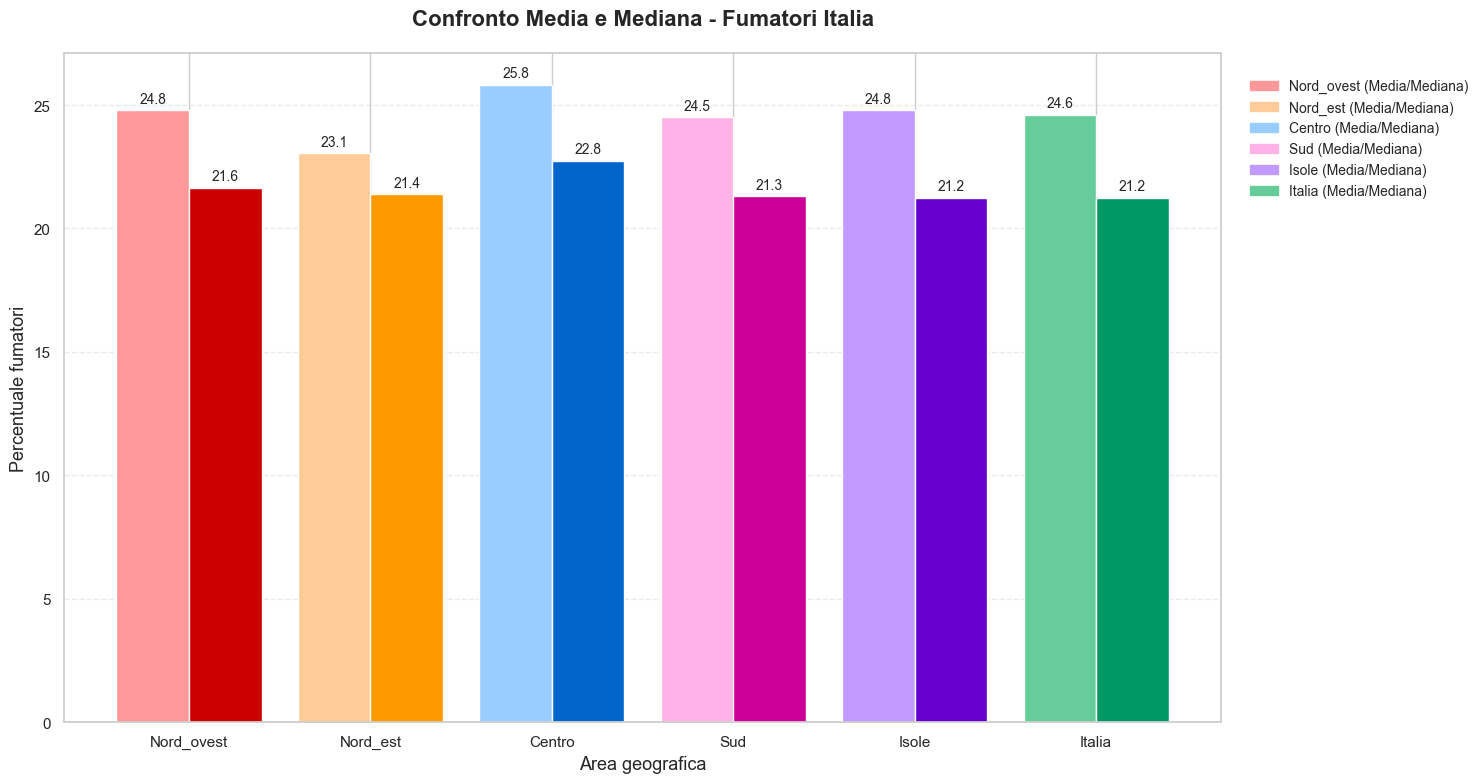

In [442]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Definizione delle colonne numeriche 
colonne_numeriche = ["Nord_ovest", "Nord_est", "Centro", "Sud", "Isole", "Italia"]

# Calcolo della media e della mediana 
media = df[colonne_numeriche].mean()
mediana = df[colonne_numeriche].median()

# Impostazione delle posizioni delle barre sull'asse X
x = range(len(colonne_numeriche))

# figura 
plt.figure(figsize=(15, 8))

# Palette colori 
colori_media = ["#ff9999", "#ffcc99", "#99ccff", "#ffb3e6", "#c299ff", "#66cc99"]
colori_mediana = ["#cc0000", "#ff9900", "#0066cc", "#cc0099", "#6600cc", "#009966"]

# Generazione delle barre relative alla Media
plt.bar(x, media, width=0.4, color=colori_media)

# Generazione delle barre relative alla Mediana
plt.bar([i + 0.4 for i in x], mediana, width=0.4, color=colori_mediana)

# Configurazione dei nomi delle etichette sull'asse X
plt.xticks([i + 0.2 for i in x], colonne_numeriche, fontsize=11)

# Aggiunta del titolo principale e delle etichette 
plt.title(
    "Confronto Media e Mediana - Fumatori Italia",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Area geografica", fontsize=13)
plt.ylabel("Percentuale fumatori", fontsize=13)

# Attivazione della griglia di sfondo solo sull'asse Y
plt.grid(axis="y", linestyle="--", alpha=0.4)

# legenda
elementi_legenda = [
    
    # Spazio vuoto 
    mpatches.Patch(color="none", label=""),
    # Sezione Aree Geografiche
    mpatches.Patch(color="#ff9999", label="Nord_ovest (Media/Mediana)"),
    mpatches.Patch(color="#ffcc99", label="Nord_est (Media/Mediana)"),
    mpatches.Patch(color="#99ccff", label="Centro (Media/Mediana)"),
    mpatches.Patch(color="#ffb3e6", label="Sud (Media/Mediana)"),
    mpatches.Patch(color="#c299ff", label="Isole (Media/Mediana)"),
    mpatches.Patch(color="#66cc99", label="Italia (Media/Mediana)"),
]


plt.legend(
    handles=elementi_legenda,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),  # Inizia appena fuori dal bordo destro (1.02)
    borderaxespad=0,
)

# Inserimento dei valori numerici sopra le barre della Media
for i, valore in enumerate(media):
    plt.text(i, valore + 0.3, round(valore, 1), ha="center", fontsize=10)

# Inserimento dei valori numerici sopra le barre della Mediana
for i, valore in enumerate(mediana):
    plt.text(i + 0.4, valore + 0.3, round(valore, 1), ha="center", fontsize=10)

# Visualizzazione finale del grafico ottimizzato
plt.tight_layout()
plt.show()

##### In molte colonne la media è più alta della mediana.
##### Questo significa che i valori alti degli anni iniziali alzano la media.

### MEDIA E DEVIAZIONE STANDARD:
###### Sud e Isole hanno una deviazione standard più alta.Questo indica maggiore variazione nel tempo.


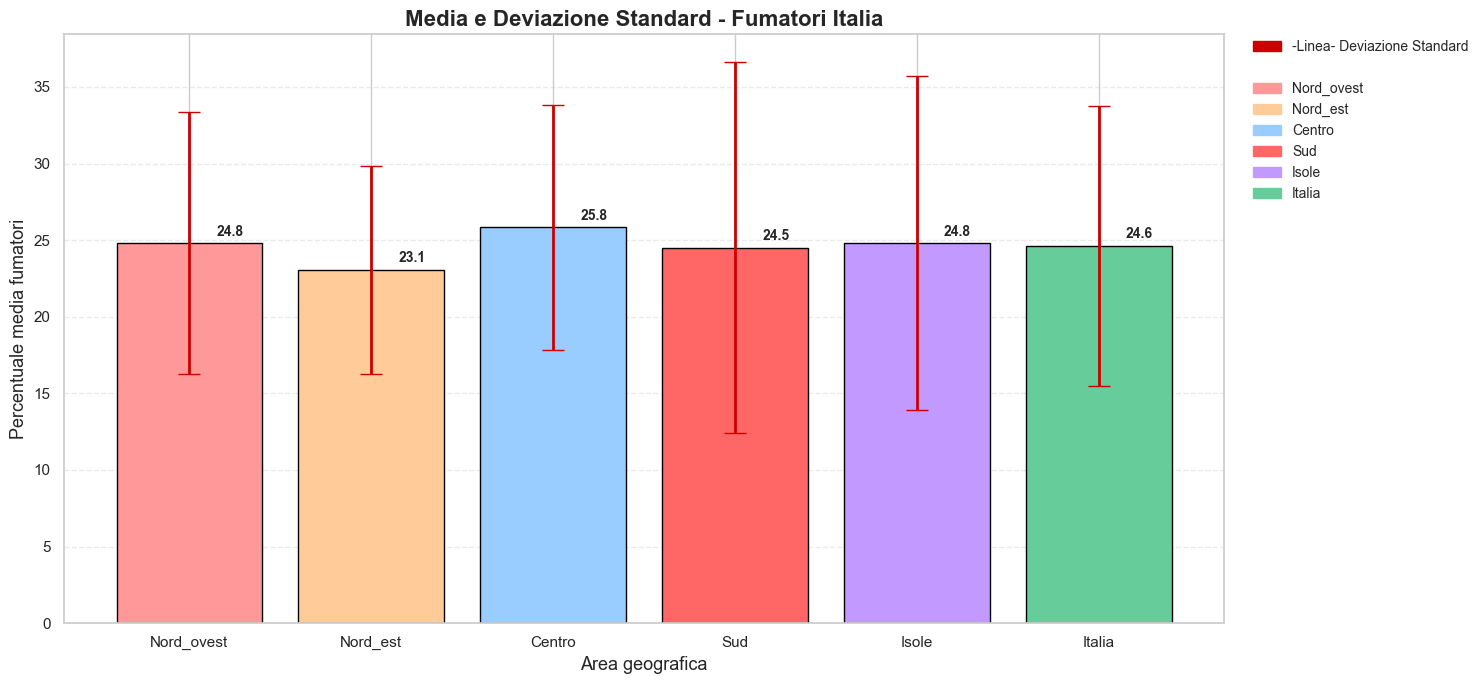

In [443]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Definizione delle colonne numeriche da analizzare
colonne_numeriche = ["Nord_ovest", "Nord_est", "Centro", "Sud", "Isole", "Italia"]

# Calcolo della media e della deviazione standard per ciascuna colonna
media = df[colonne_numeriche].mean()
dev_std = df[colonne_numeriche].std()

# figura 
plt.figure(figsize=(15, 7))

# Generazione del grafico a barre
bars = plt.bar(
    colonne_numeriche,
    media,
    yerr=dev_std,
    capsize=8,
    color=["#ff9999", "#ffcc99", "#99ccff", "#ff6666", "#c299ff", "#66cc99"],
    edgecolor="black",
    error_kw={
        "ecolor": "#cc0000",
        "elinewidth": 2,
    },  
)

# Aggiunta del titolo principale e delle etichette degli assi
plt.title(
    "Media e Deviazione Standard - Fumatori Italia",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Area geografica", fontsize=13)
plt.ylabel("Percentuale media fumatori", fontsize=13)

# Attivazione della griglia di sfondo
plt.grid(axis="y", linestyle="--", alpha=0.4)

# legenda
elementi_legenda = [

        mpatches.Patch(color="#cc0000", label="-Linea- Deviazione Standard"),
    mpatches.Patch(color="none", label=""),  # Spazio vuoto divisore
    # aree geografiche
    mpatches.Patch(color="#ff9999", label="Nord_ovest"),
    mpatches.Patch(color="#ffcc99", label="Nord_est"),
    mpatches.Patch(color="#99ccff", label="Centro"),
    mpatches.Patch(color="#ff6666", label="Sud"),
    mpatches.Patch(color="#c299ff", label="Isole"),
    mpatches.Patch(color="#66cc99", label="Italia"),
]

# legenda
plt.legend(
    handles=elementi_legenda,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
)

# Inserimento dei valori numerici
for bar, valore in zip(bars, media):
    pos_x = bar.get_x() + bar.get_width() / 2 + 0.15
    pos_y = bar.get_height() + 0.5

    plt.text(
        pos_x,
        pos_y,
        round(valore, 1),
        ha="left", 
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


### ANALISI PERCENTILI:
###### 25° Percentile: il 25% delle osservazioni totali si attesta sotto questo valore.
###### 50° Percentile(mediana): divide esattamente a metà il dataset. Essendo i dati maschili e femminili in numero uguale.
###### In molte colonne la media è leggermente più alta del 50%.
###### Questo indica che alcuni anni con percentuali elevate aumentano la media generale.
###### 75° Percentile: il 75% dei dati è inferiore a questo valore,
###### I valori sopra il 75% rappresentano gli anni con percentuali di fumatori più elevate.
### Differenza tra 25% e 75%:
###### La distanza tra questi percentili mostra la dispersione dei dati nel tempo.
##### Italia:
###### mostra una diminuzione progressiva dei fumatori nel corso degli anni.

In [444]:
#grafico analisi 